# Phase 1: Passive Tracer Verification

Verifies that passive tracers are correctly advected by the MPAS dynamical core.

| Tracer | Initialization | Expected behavior |
|--------|---------------|-------------------|
| `tracer_1` | Gaussian blob at 45°N, 0°E, mid-level | Advects with flow, diffuses slightly |
| `tracer_2` | Uniform background = 1.0 kg/kg | Stays exactly 1.0 everywhere |
| `tracer_3` | Surface-concentrated exponential decay | Vertical profile preserved, horizontal advection |

**Checks:** Mass conservation (area-weighted), no negative values (monotonic limiter),
uniform tracer stays uniform, spatial coherence of Gaussian blob.

**Pre-requisite:** Run the JW test with tracers enabled (see `verification/README.md`).
Expects `data/jw_480km_chapman/output.nc` with `tracer_1`, `tracer_2`, `tracer_3`.

In [1]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("..") / "data" / "jw_480km_chapman"
OUTPUT = DATA_DIR / "output.nc"
assert OUTPUT.exists(), f"Run the JW test first — {OUTPUT} not found"

ds = nc.Dataset(OUTPUT)
lat = np.degrees(ds["latCell"][:])
lon = np.degrees(ds["lonCell"][:])
areaCell = ds["areaCell"][:]
nTimes = ds.dimensions["Time"].size
nCells = ds.dimensions["nCells"].size
nLevels = ds.dimensions["nVertLevels"].size

tracer_names = ["tracer_1", "tracer_2", "tracer_3"]
for tv in tracer_names:
    assert tv in ds.variables, f"Variable {tv} not found in {OUTPUT}"

print(f"Grid: {nCells} cells, {nLevels} levels, {nTimes} time steps")
print(f"Tracers found: {tracer_names}")

Grid: 2562 cells, 26 levels, 25 time steps
Tracers found: ['tracer_1', 'tracer_2', 'tracer_3']


## 1. Tracer Mass Conservation

Area-weighted mass for each tracer over time. Since tracers are mixing ratios and
we lack explicit density in the output, we compute an area-weighted integral as a
proxy: $M(t) = \sum_{\text{cells}} \sum_{\text{levels}} q(t) \cdot A_{\text{cell}}$.

For the monotonic transport scheme, this should be very nearly conserved.

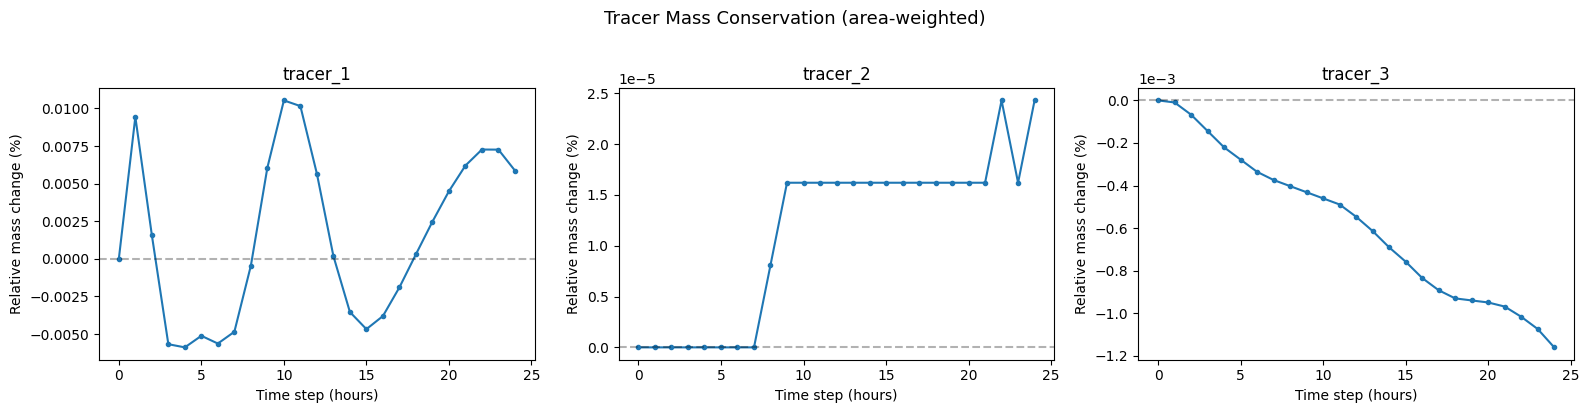

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
hours = np.arange(nTimes)
mass_changes = {}

for ax, tv in zip(axes, tracer_names):
    # Area-weighted sum over cells and levels
    mass = np.zeros(nTimes)
    for t in range(nTimes):
        data = ds[tv][t, :, :]  # (nCells, nLevels)
        mass[t] = np.sum(data * areaCell[:, np.newaxis])

    rel_change = (mass - mass[0]) / mass[0] if mass[0] != 0 else mass - mass[0]
    mass_changes[tv] = rel_change

    ax.plot(hours, rel_change * 100, "o-", markersize=3, color="C0")
    ax.set_xlabel("Time step (hours)")
    ax.set_ylabel("Relative mass change (%)")
    ax.set_title(f"{tv}")
    ax.axhline(0, color="k", linestyle="--", alpha=0.3)
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))

fig.suptitle("Tracer Mass Conservation (area-weighted)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2. Spatial Distribution — Gaussian Blob (tracer_1)

Maps of `tracer_1` at mid-level, initial vs final time. The Gaussian blob should
advect with the baroclinic wave flow while preserving its shape.

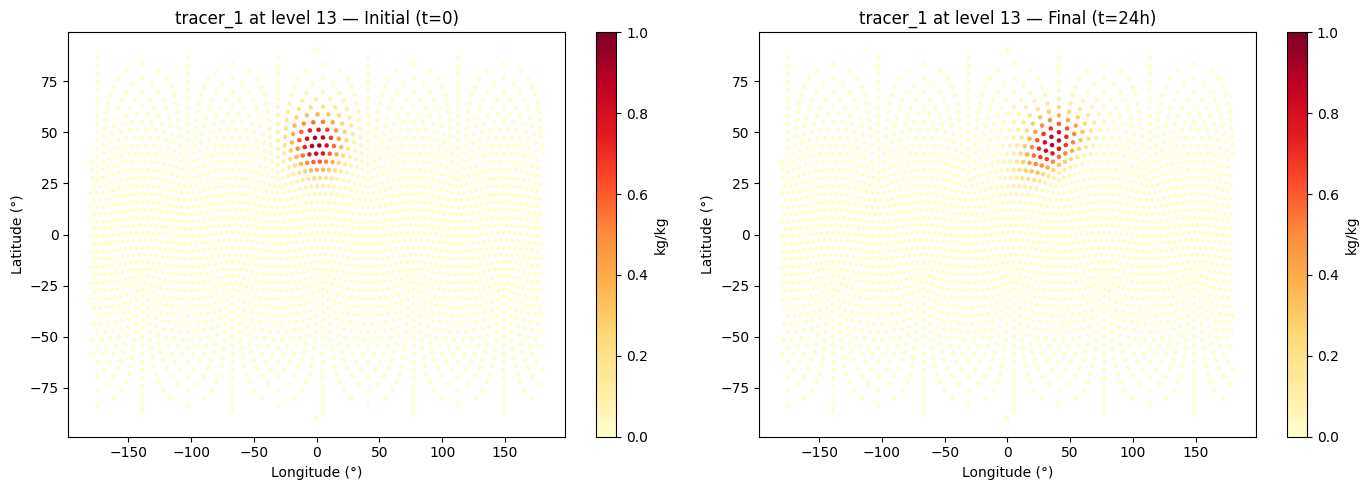

In [3]:
mid_k = nLevels // 2  # mid-level where Gaussian blob is centered

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, t, label in zip(axes, [0, -1], ["Initial (t=0)", f"Final (t={nTimes-1}h)"]):
    vals = ds["tracer_1"][t, :, mid_k]
    sc = ax.scatter(lon, lat, c=vals, s=5, cmap="YlOrRd", vmin=0, vmax=1)
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")
    ax.set_title(f"tracer_1 at level {mid_k} — {label}")
    plt.colorbar(sc, ax=ax, label="kg/kg")
plt.tight_layout()
plt.show()

## 3. Vertical Profiles

Vertical profiles of each tracer at the initial and final time, averaged over
cells near 45°N (where the Gaussian blob is centered).

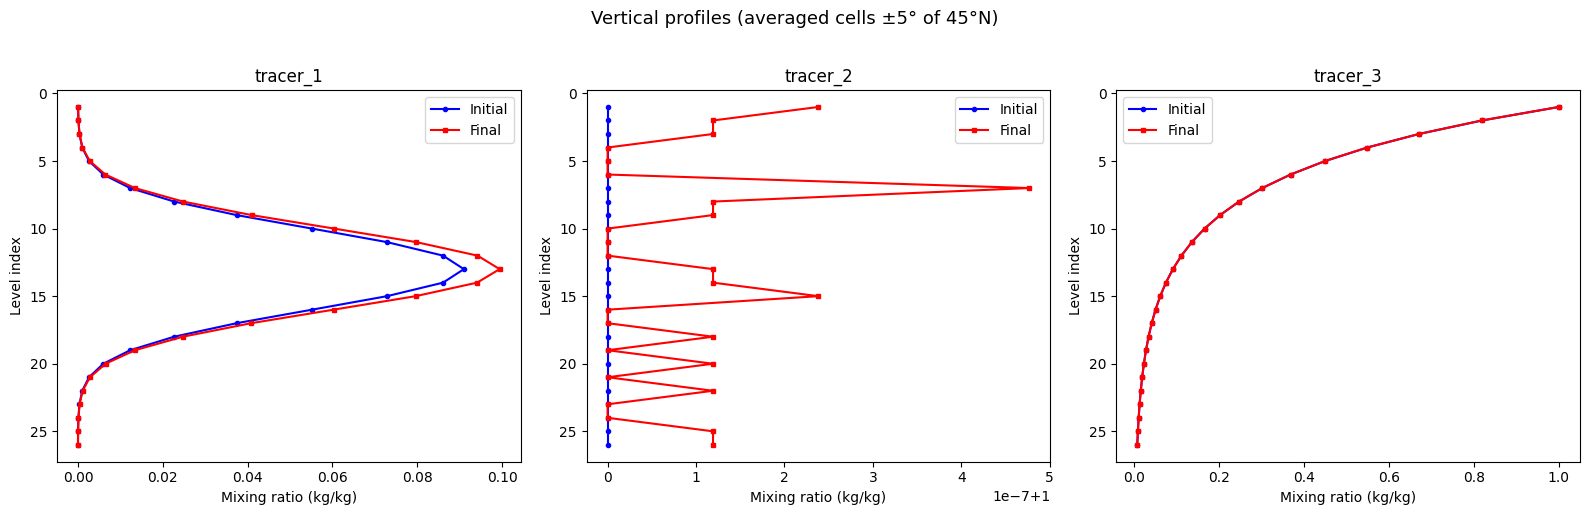

In [4]:
# Select cells near 45°N
mask_45N = np.abs(lat - 45) < 5  # ±5° band
levels = np.arange(1, nLevels + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, tv in zip(axes, tracer_names):
    profile_init = ds[tv][0, mask_45N, :].mean(axis=0)
    profile_final = ds[tv][-1, mask_45N, :].mean(axis=0)
    ax.plot(profile_init, levels, "b-o", markersize=3, label="Initial")
    ax.plot(profile_final, levels, "r-s", markersize=3, label="Final")
    ax.set_xlabel("Mixing ratio (kg/kg)")
    ax.set_ylabel("Level index")
    ax.set_title(tv)
    ax.legend()
    ax.invert_yaxis()

fig.suptitle("Vertical profiles (averaged cells ±5° of 45°N)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Uniform Tracer (tracer_2) Stability

`tracer_2` was initialized as 1.0 everywhere. Any deviation from 1.0 at any
time/level/cell indicates a problem with the transport scheme.

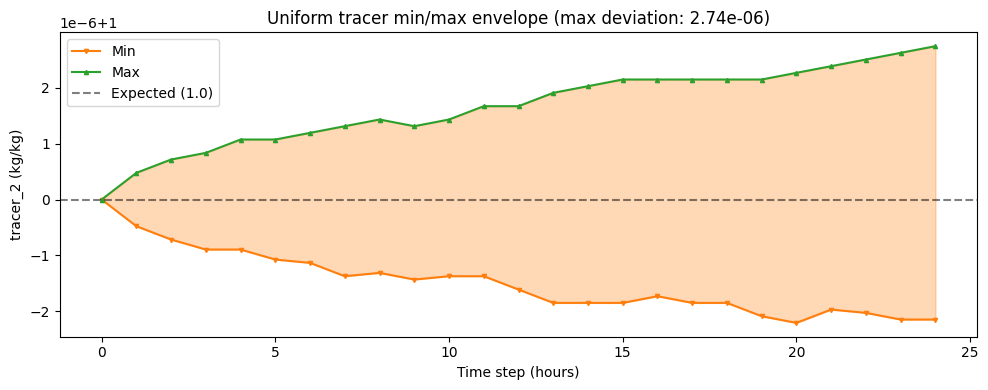

In [5]:
t2_data = ds["tracer_2"][:]  # (nTimes, nCells, nLevels)
t2_max_dev = np.abs(t2_data - 1.0).max()
t2_min = t2_data.min()
t2_max = t2_data.max()

# Time series of min/max
fig, ax = plt.subplots(figsize=(10, 4))
t2_tmin = np.array([ds["tracer_2"][t, :, :].min() for t in range(nTimes)])
t2_tmax = np.array([ds["tracer_2"][t, :, :].max() for t in range(nTimes)])
ax.fill_between(hours, t2_tmin, t2_tmax, alpha=0.3, color="C1")
ax.plot(hours, t2_tmin, "v-", markersize=3, color="C1", label="Min")
ax.plot(hours, t2_tmax, "^-", markersize=3, color="C2", label="Max")
ax.axhline(1.0, color="k", linestyle="--", alpha=0.5, label="Expected (1.0)")
ax.set_xlabel("Time step (hours)")
ax.set_ylabel("tracer_2 (kg/kg)")
ax.set_title(f"Uniform tracer min/max envelope (max deviation: {t2_max_dev:.2e})")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Surface-Concentrated Tracer (tracer_3)

Maps of `tracer_3` at the lowest level (k=0) for initial and final time.
This tracer starts with `exp(-(k-1)/5)`, so level 0 ≈ 1.0, level 25 ≈ 0.007.

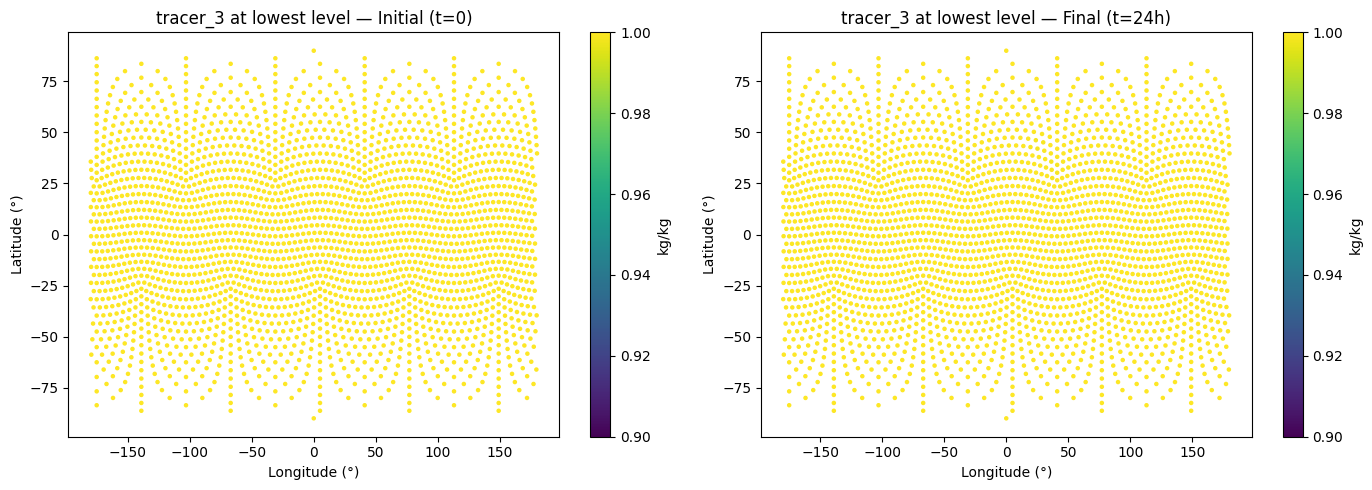

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, t, label in zip(axes, [0, -1], ["Initial (t=0)", f"Final (t={nTimes-1}h)"]):
    vals = ds["tracer_3"][t, :, 0]  # lowest level
    sc = ax.scatter(lon, lat, c=vals, s=5, cmap="viridis", vmin=0.9, vmax=1.0)
    ax.set_xlabel("Longitude (°)")
    ax.set_ylabel("Latitude (°)")
    ax.set_title(f"tracer_3 at lowest level — {label}")
    plt.colorbar(sc, ax=ax, label="kg/kg")
plt.tight_layout()
plt.show()

## 6. Automated Pass/Fail Checks

In [7]:
results = []

# Check 1: All tracers present
check = all(tv in ds.variables for tv in tracer_names)
results.append(("All 3 tracers in output", check))

# Check 2: No negative values (monotonic limiter)
for tv in tracer_names:
    min_val = ds[tv][:].min()
    ok = min_val >= 0.0
    results.append((f"{tv} non-negative (min={min_val:.3e})", ok))

# Check 3: Uniform tracer stays near 1.0 (tolerance 1e-4)
t2_all = ds["tracer_2"][:]
t2_dev = np.abs(t2_all - 1.0).max()
results.append((f"tracer_2 uniform (max dev={t2_dev:.3e})", t2_dev < 1e-4))

# Check 4: Gaussian blob peak decreases (diffusion is OK) but doesn't vanish
t1_peak_init = ds["tracer_1"][0, :, :].max()
t1_peak_final = ds["tracer_1"][-1, :, :].max()
results.append((f"tracer_1 blob survived (init={t1_peak_init:.3f}, final={t1_peak_final:.3f})",
                t1_peak_final > 0.1))

# Check 5: Area-weighted mass conservation for tracer_1 (< 1% change)
mass_t1 = np.zeros(nTimes)
for t in range(nTimes):
    mass_t1[t] = np.sum(ds["tracer_1"][t, :, :] * areaCell[:, np.newaxis])
mass_change = abs(mass_t1[-1] - mass_t1[0]) / mass_t1[0] if mass_t1[0] != 0 else 0
results.append((f"tracer_1 mass conserved (change={mass_change:.3e})", mass_change < 0.01))

# Report
print("Phase 1 Verification Results")
print("=" * 60)
all_pass = True
for name, passed in results:
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}] {name}")
print("=" * 60)
print(f"  Phase 1: {'ALL CHECKS PASSED' if all_pass else 'SOME CHECKS FAILED'}")

ds.close()

Phase 1 Verification Results
  [PASS] All 3 tracers in output
  [PASS] tracer_1 non-negative (min=0.000e+00)
  [PASS] tracer_2 non-negative (min=1.000e+00)
  [PASS] tracer_3 non-negative (min=6.738e-03)
  [PASS] tracer_2 uniform (max dev=2.742e-06)
  [PASS] tracer_1 blob survived (init=0.979, final=0.918)
  [PASS] tracer_1 mass conserved (change=5.868e-05)
  Phase 1: ALL CHECKS PASSED
